# 11 Taxa

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("results_11-taxa-weighted-quartets.csv")

In [3]:
tree1 = "(((((1,2),3),4),((((5,6),(7,8)),9),10)),11);"
tree2 = "(((((1.1,2.2),3.3),4.4),((((5.5,6.6),(7.7,8.8)),9.9),10.10)),11.11);"

df["model_tree"] = [tree1 if i < 100 else tree2 for i in range(len(df))]

In [4]:
import sys
sys.path.insert(0, ".")
sys.setrecursionlimit(10_000_000)
import dendropy
from robinson_foulds import robinson_foulds_distance

def rf_rate(newick1, newick2):
    tns = dendropy.TaxonNamespace()
    t1 = dendropy.Tree.get(data=newick1, schema="newick", taxon_namespace=tns)
    t2 = dendropy.Tree.get(data=newick2, schema="newick", taxon_namespace=tns)
    return robinson_foulds_distance(t1, t2)

df["rf_rate_wqfm"] = df.apply(lambda r: rf_rate(r["algo1_wqfm_tree"], r["model_tree"]), axis=1)
df["rf_rate_qubo"] = df.apply(lambda r: rf_rate(r["algo2_qubo_tree"], r["model_tree"]), axis=1)

In [5]:
wqfm_wins = (df["rf_rate_wqfm"] < df["rf_rate_qubo"]).sum()
qubo_wins = (df["rf_rate_qubo"] < df["rf_rate_wqfm"]).sum()
draws      = (df["rf_rate_wqfm"] == df["rf_rate_qubo"]).sum()

print(f"WQFM better : {wqfm_wins}")
print(f"QUBO better : {qubo_wins}")
print(f"Draws       : {draws}")

WQFM better : 3
QUBO better : 4
Draws       : 193


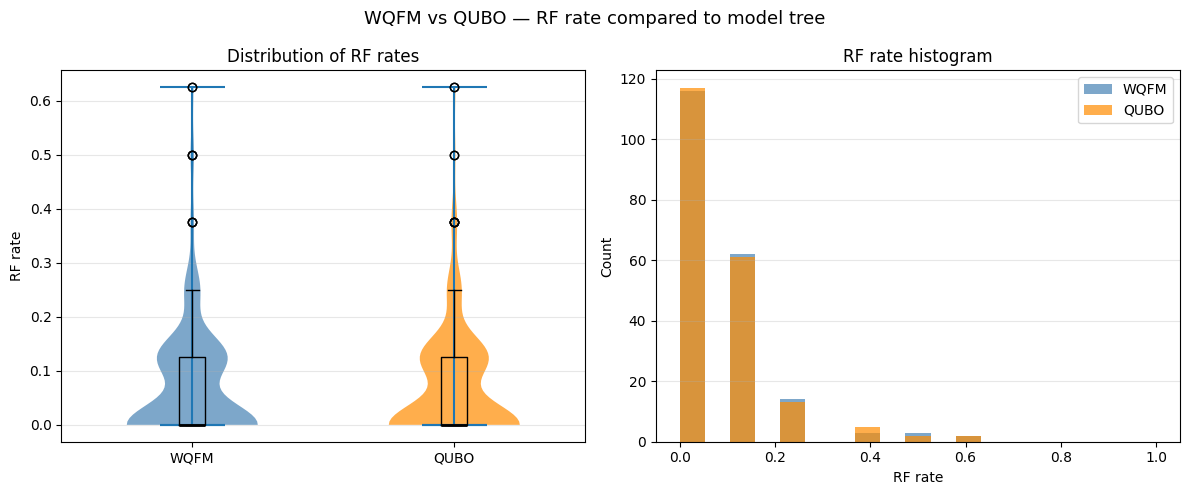

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: Violin + box overlay ---
data = [df["rf_rate_wqfm"], df["rf_rate_qubo"]]
parts = axes[0].violinplot(data, positions=[1, 2], showmedians=True, showextrema=True)
for pc, color in zip(parts["bodies"], ["steelblue", "darkorange"]):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
axes[0].boxplot(data, positions=[1, 2], widths=0.1, patch_artist=False,
                medianprops=dict(color="black", linewidth=2))
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["WQFM", "QUBO"])
axes[0].set_ylabel("RF rate")
axes[0].set_title("Distribution of RF rates")
axes[0].grid(True, alpha=0.3, axis="y")

# --- Right: Histogram ---
bins = np.linspace(0, 1, 20)
axes[1].hist(df["rf_rate_wqfm"], bins=bins, alpha=0.7, label="WQFM", color="steelblue")
axes[1].hist(df["rf_rate_qubo"], bins=bins, alpha=0.7, label="QUBO", color="darkorange")
axes[1].set_xlabel("RF rate")
axes[1].set_ylabel("Count")
axes[1].set_title("RF rate histogram")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("WQFM vs QUBO — RF rate compared to model tree", fontsize=13)
plt.tight_layout()
plt.show()

# 15 Taxa

In [7]:
df = pd.read_csv('results_15-taxa-weighted-quartets.csv')

In [8]:
model_tree = "((((((((((((((A,B),C),D),E),F),G),H),I),J),K),L),M),N),O);"
df["model_tree"] = model_tree
df["rf_rate_wqfm"] = df.apply(lambda r: rf_rate(r["algo1_wqfm_tree"], r["model_tree"]), axis=1)
df["rf_rate_qubo"] = df.apply(lambda r: rf_rate(r["algo2_qubo_tree"], r["model_tree"]), axis=1)


In [9]:
wqfm_wins = (df["rf_rate_wqfm"] < df["rf_rate_qubo"]).sum()
qubo_wins = (df["rf_rate_qubo"] < df["rf_rate_wqfm"]).sum()
draws      = (df["rf_rate_wqfm"] == df["rf_rate_qubo"]).sum()

print(f"WQFM better : {wqfm_wins}")
print(f"QUBO better : {qubo_wins}")
print(f"Draws       : {draws}")

WQFM better : 3
QUBO better : 5
Draws       : 52


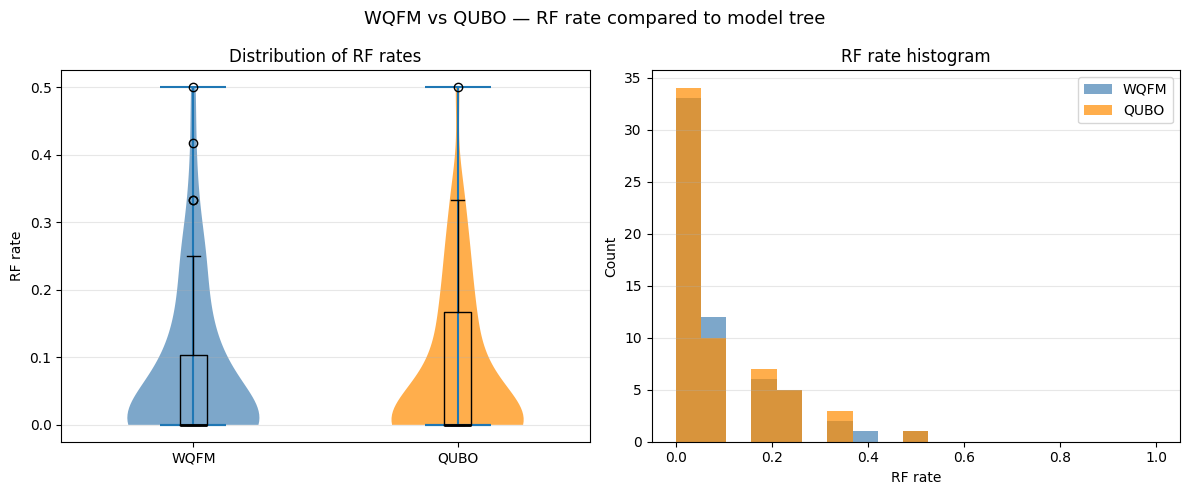

In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: Violin + box overlay ---
data = [df["rf_rate_wqfm"], df["rf_rate_qubo"]]
parts = axes[0].violinplot(data, positions=[1, 2], showmedians=True, showextrema=True)
for pc, color in zip(parts["bodies"], ["steelblue", "darkorange"]):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
axes[0].boxplot(data, positions=[1, 2], widths=0.1, patch_artist=False,
                medianprops=dict(color="black", linewidth=2))
axes[0].set_xticks([1, 2])
axes[0].set_xticklabels(["WQFM", "QUBO"])
axes[0].set_ylabel("RF rate")
axes[0].set_title("Distribution of RF rates")
axes[0].grid(True, alpha=0.3, axis="y")

# --- Right: Histogram ---
bins = np.linspace(0, 1, 20)
axes[1].hist(df["rf_rate_wqfm"], bins=bins, alpha=0.7, label="WQFM", color="steelblue")
axes[1].hist(df["rf_rate_qubo"], bins=bins, alpha=0.7, label="QUBO", color="darkorange")
axes[1].set_xlabel("RF rate")
axes[1].set_ylabel("Count")
axes[1].set_title("RF rate histogram")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("WQFM vs QUBO — RF rate compared to model tree", fontsize=13)
plt.tight_layout()
plt.show()

# 37 Taxa


In [11]:
df = pd.read_csv('results_37-taxa-weighted-quartets.csv')

model_tree = "(GAL,(ORN,(((((PRO,LOX),ECH),(DAS,CHO)),((((OTO,MIC),((CAL,((PON,(GOR,(HOM,PAN))),NEW)),TAR)),(((OCH,ORY),(SPE,((DIP,(RAT,MUS)),CAV))),TUP)),(((PTE,MYO),((EQU,(FEL,CAN)),((SUS,(BOS,TUR)),VIC))),(ERI,SOR)))),(MON,MAC))));"
df["model_tree"] = model_tree

df["rf_rate_wqfm"] = df.apply(lambda r: rf_rate(r["algo1_wqfm_tree"], r["model_tree"]), axis=1)
df["rf_rate_qubo"] = df.apply(lambda r: rf_rate(r["algo2_qubo_tree"], r["model_tree"]), axis=1)

wqfm_wins = (df["rf_rate_wqfm"] < df["rf_rate_qubo"]).sum()
qubo_wins = (df["rf_rate_qubo"] < df["rf_rate_wqfm"]).sum()
draws      = (df["rf_rate_wqfm"] == df["rf_rate_qubo"]).sum()

print(f"WQFM better : {wqfm_wins}")
print(f"QUBO better : {qubo_wins}")
print(f"Draws       : {draws}")

WQFM better : 3
QUBO better : 1
Draws       : 94
